# Vision-Based Landslide Forecasting: ResNet50 Model

This notebook trains the **ResNet50 (Proposed Model)** using PyTorch, aligning with the assignment's forecasting strategy and preventing data leakage via geographic splitting.

In [6]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Geographic Data Split (Preventing Data Leakage)
We use `GroupShuffleSplit` on `landslide_id` so that positive samples and their paired negative samples remain in the same split. This guarantees the test set is geographically independent.

In [7]:
metadata_path = 'dataset_version_2/metadata.csv'
df = pd.read_csv(metadata_path)

# Ensure files exist
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)
print(f"Total valid images: {len(df)}")

# Train (70%), Val (15%), Test (15%)
gss1 = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss1.split(df, groups=df['landslide_id']))

df_train = df.iloc[train_idx].copy()
df_temp = df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(df_temp, groups=df_temp['landslide_id']))

df_val = df_temp.iloc[val_idx].copy()
df_test = df_temp.iloc[test_idx].copy()

print(f"Train size: {len(df_train)} | Val size: {len(df_val)} | Test size: {len(df_test)}")

Total valid images: 8338
Train size: 5836 | Val size: 1255 | Test size: 1247


## 2. PyTorch Custom Dataset

In [8]:
class LandslideDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        label = float(self.dataframe.iloc[idx]['label'])
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.float32)

# Transforms with Data Augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

batch_size = 32
train_loader = DataLoader(LandslideDataset(df_train, train_transform), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(LandslideDataset(df_val, val_test_transform), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(LandslideDataset(df_test, val_test_transform), batch_size=batch_size, shuffle=False)

## 3. Training & Evaluation Functions

In [9]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=20, patience=5, save_path='best_model.pth'):
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                probs = torch.sigmoid(outputs)
                val_preds.extend(probs.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())
                
        epoch_val_loss = val_loss / len(val_loader.dataset)
        scheduler.step(epoch_val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break
    model.load_state_dict(torch.load(save_path, weights_only=True))
    return model

def evaluate_model(model, name):
    model.eval()
    test_preds, test_targets = [], []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            test_preds.extend(probs.cpu().numpy())
            test_targets.extend(labels.numpy())
            
    y_true = np.array(test_targets).flatten()
    y_prob = np.array(test_preds).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    
    print(f"\n{'='*40}\n--- Evaluation: {name} ---\n{'='*40}")
    print(classification_report(y_true, y_pred, target_names=['No Landslide', 'Landslide']))
    
    # Specificity & AUC
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_true, y_prob)
    
    print(f"Specificity:  {specificity:.4f}")
    print(f"ROC-AUC:      {auc:.4f}")
    print(f"TP: {tp}  TN: {tn}  FP: {fp}  FN: {fn}")
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Landslide', 'Landslide'], 
                yticklabels=['No Landslide', 'Landslide'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'saved_models/{name.replace(" ", "_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    return {'name': name, 'f1': f1_score(y_true, y_pred, pos_label=1), 'auc': auc, 'specificity': specificity, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}


## 4. ResNet50 Transfer Learning

Stage 1: Training ResNet50 (Head only)...
Epoch 1/15 | Train Loss: 0.6893 | Val Loss: 0.6830
Epoch 2/15 | Train Loss: 0.6808 | Val Loss: 0.6746
Epoch 3/15 | Train Loss: 0.6727 | Val Loss: 0.6673
Epoch 4/15 | Train Loss: 0.6677 | Val Loss: 0.6637
Epoch 5/15 | Train Loss: 0.6640 | Val Loss: 0.6623
Epoch 6/15 | Train Loss: 0.6616 | Val Loss: 0.6598
Epoch 7/15 | Train Loss: 0.6594 | Val Loss: 0.6588
Epoch 8/15 | Train Loss: 0.6584 | Val Loss: 0.6561
Epoch 9/15 | Train Loss: 0.6504 | Val Loss: 0.6526
Epoch 10/15 | Train Loss: 0.6539 | Val Loss: 0.6534
Epoch 11/15 | Train Loss: 0.6491 | Val Loss: 0.6507
Epoch 12/15 | Train Loss: 0.6517 | Val Loss: 0.6499
Epoch 13/15 | Train Loss: 0.6433 | Val Loss: 0.6506
Epoch 14/15 | Train Loss: 0.6417 | Val Loss: 0.6452
Epoch 15/15 | Train Loss: 0.6424 | Val Loss: 0.6453

Stage 2: Fine-tuning ResNet50 upper layers...
Epoch 1/10 | Train Loss: 0.6415 | Val Loss: 0.6494
Epoch 2/10 | Train Loss: 0.6356 | Val Loss: 0.6446
Epoch 3/10 | Train Loss: 0.6313 | Val 

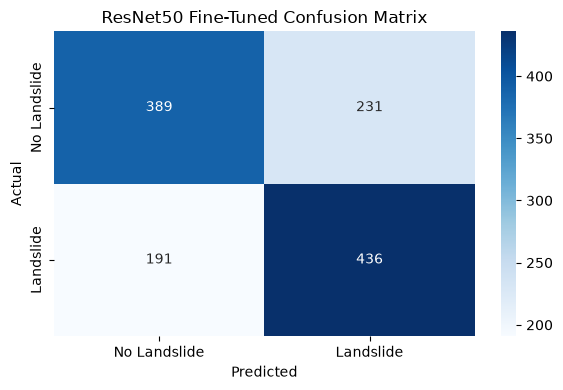


Final Results: {'name': 'ResNet50 Fine-Tuned', 'f1': 0.6738794435857806, 'auc': 0.713541184339147, 'specificity': np.float64(0.6274193548387097), 'tp': np.int64(436), 'tn': np.int64(389), 'fp': np.int64(231), 'fn': np.int64(191)}


In [10]:
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze base model
for param in resnet_model.parameters():
    param.requires_grad = False

# Replace head
resnet_model.fc = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 256), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256, 1)
)
resnet_model = resnet_model.to(device)

# Handle class imbalance
pos_count = df_train['label'].sum()
neg_count = len(df_train) - pos_count
pos_weight = torch.tensor([neg_count / pos_count]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_res = optim.Adam(resnet_model.fc.parameters(), lr=1e-4)
scheduler_res = optim.lr_scheduler.ReduceLROnPlateau(optimizer_res, mode='min', factor=0.5, patience=3)

print("Stage 1: Training ResNet50 (Head only)...")
resnet_model = train_model(resnet_model, criterion, optimizer_res, scheduler_res, num_epochs=15, patience=4, save_path='saved_models/resnet50_stage1.pth')

# Stage 2: Fine-Tuning
print("\nStage 2: Fine-tuning ResNet50 upper layers...")
for name, child in resnet_model.named_children():
    if name in ['layer4', 'fc']:
        for param in child.parameters():
            param.requires_grad = True

optimizer_ft = optim.Adam([
    {'params': resnet_model.layer4.parameters(), 'lr': 1e-5},
    {'params': resnet_model.fc.parameters(), 'lr': 1e-4}
])
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=3)

resnet_model = train_model(resnet_model, criterion, optimizer_ft, scheduler_ft, num_epochs=10, patience=4, save_path='saved_models/resnet50_best.pth')
results = evaluate_model(resnet_model, 'ResNet50 Fine-Tuned')
print('\nFinal Results:', results)


In [11]:
# Save final model
os.makedirs('saved_models', exist_ok=True)
torch.save(resnet_model.state_dict(), 'saved_models/resnet50_final.pth')
print("ResNet50 model saved successfully!")

ResNet50 model saved successfully!
